In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
import struct

# https://web.archive.org/web/20200722154330/http://yann.lecun.com/exdb/mnist/#:~:text=FILE%20FORMATS

# https://docs.python.org/3/library/struct.html

def read_idx_images(filename):
    with open(filename, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        assert magic == 2051, f"Invalid magic number for images: {magic}"
        num_images = struct.unpack('>I', f.read(4))[0]
        rows = struct.unpack('>I', f.read(4))[0]
        cols = struct.unpack('>I', f.read(4))[0]
        images = []
        for _ in range(num_images):
            image = []
            for _ in range(rows):
                row = []
                for _ in range(cols):
                    pixel = struct.unpack('>B', f.read(1))[0]
                    row.append(pixel)
                image.append(row)
            images.append(image)
        return images

def read_idx_labels(filename):
    with open(filename, 'rb') as f:
        magic = struct.unpack('>I', f.read(4))[0]
        assert magic == 2049, f"Invalid magic number for labels: {magic}"
        num_labels = struct.unpack('>I', f.read(4))[0]
        labels = [struct.unpack('>B', f.read(1))[0]
                  for _ in range(num_labels)]
        return labels

In [10]:
train_images = read_idx_images(f"mnist/train-images-idx3-ubyte")
train_labels = read_idx_labels(f"mnist/train-labels-idx1-ubyte")
test_images = read_idx_images(f"mnist/t10k-images-idx3-ubyte")
test_labels = read_idx_labels(f"mnist/t10k-labels-idx1-ubyte")

In [11]:
def display(image):
    plt.figure(figsize=(1, 1))
    plt.axis('off')
    plt.imshow(image)

5

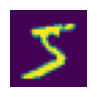

In [12]:
display(train_images[0])
train_labels[0]

7

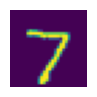

In [13]:
display(test_images[0])
test_labels[0]

In [15]:
LABELS = sorted(set(train_labels))
LABELS

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [18]:
len(LABELS)

10

In [16]:
INPUTS = 28 * 28
INPUTS

784

In [17]:
import torch
import torch.nn.functional as F

In [19]:
W = torch.randn((784, 512, 512, 10), requires_grad=True)

In [20]:
xs = torch.tensor([[pixel/255 for row in img for pixel in row] for img in train_images])

In [27]:
xs.shape, xs.dtype, xs.max().item(), xs.min().item(), f"{xs.mean().item():.4f}"

(torch.Size([60000, 784]), torch.float32, 1.0, 0.0, '0.1307')

In [28]:
ys = torch.tensor(train_labels)

In [29]:
ys.shape, ys.dtype, ys.max().item(), ys.min().item()

(torch.Size([60000]), torch.int64, 9, 0)

In [31]:
xs.shape, W.shape

(torch.Size([60000, 784]), torch.Size([784, 512, 512, 10]))

In [41]:
STEP = 0.05